In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# 1. Load dataset
df = pd.read_csv("titanic_dataset.csv")  # ensure titanic.csv is in the working directory


In [5]:
# 2. Preprocessing (example pipeline)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Fare'].fillna(df['Fare'].median(), inplace=True)
df['Cabin_present'] = df['Cabin'].notnull().astype(int)
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.').iloc[:,0].str.strip()
# Simplify titles
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})


/tmp/ipython-input-3518638961.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-3518638961.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [6]:
# Encode categorical variables
le_sex = LabelEncoder()
df['Sex_n'] = le_sex.fit_transform(df['Sex'])
df = pd.get_dummies(df, columns=['Embarked','Title'], drop_first=True)


In [7]:
# Feature selection (example)
features = ['Pclass','Sex_n','Age','Fare','SibSp','Parch','Cabin_present'] + \
           [c for c in df.columns if c.startswith('Embarked_') or c.startswith('Title_')]
X = df[features]
y = df['Survived']


In [8]:
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [9]:
# 4a. Decision Tree baseline
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt))
print('Confusion Matrix:\\n', confusion_matrix(y_test, y_pred_dt))
print('Classification Report:\\n', classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7932960893854749
Confusion Matrix:\n [[92 18]
 [19 50]]
Classification Report:\n               precision    recall  f1-score   support

           0       0.83      0.84      0.83       110
           1       0.74      0.72      0.73        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



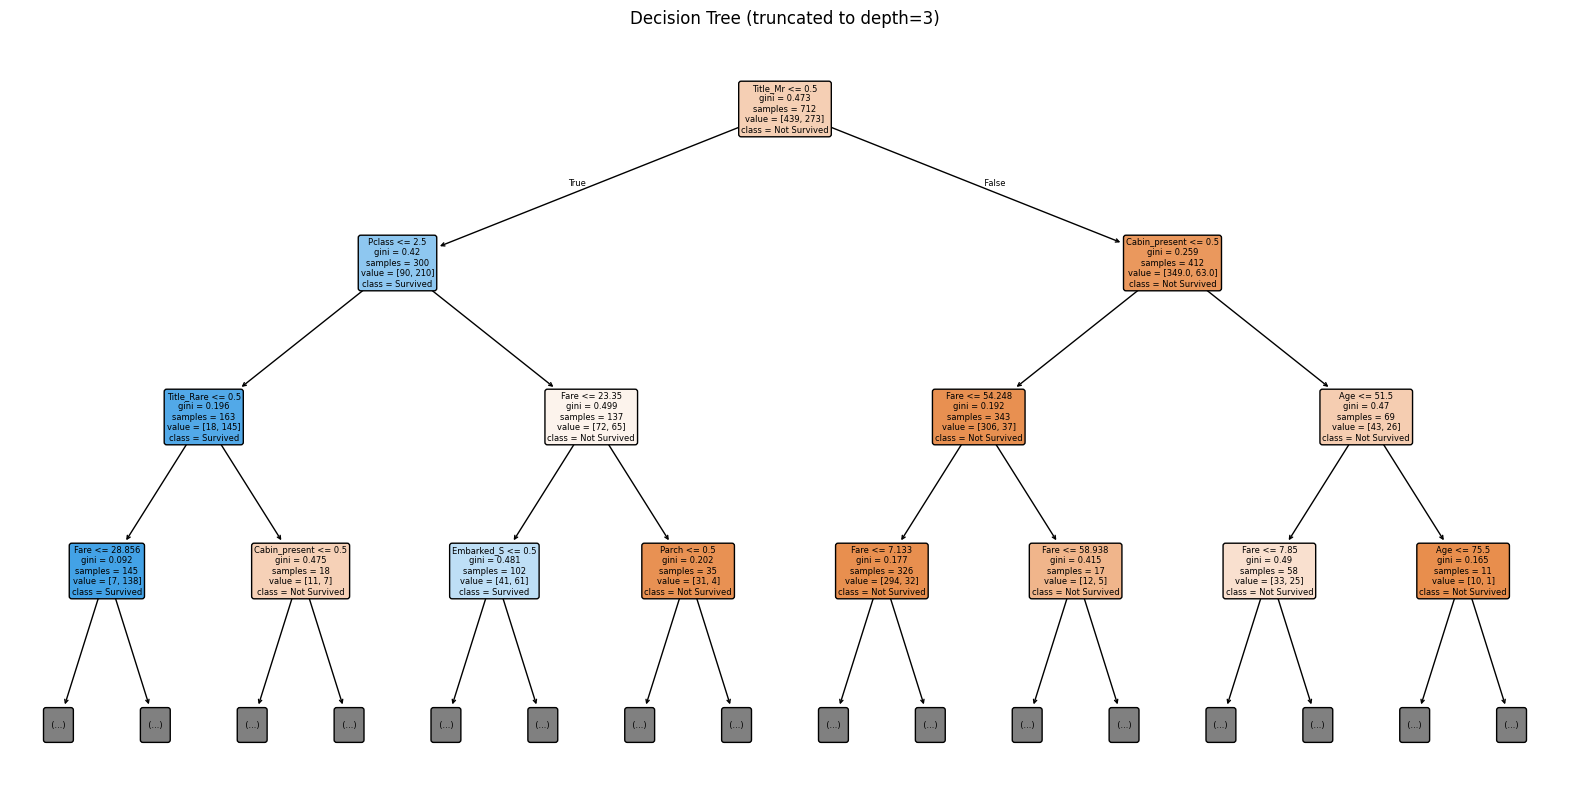

In [10]:
# Visualize tree (small trees only)
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['Not Survived','Survived'], filled=True, rounded=True, max_depth=3)
plt.title('Decision Tree (truncated to depth=3)')
plt.show()


In [11]:
# 4b. Random Forest baseline
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest Accuracy:', accuracy_score(y_test, y_pred_rf))
print('Confusion Matrix:\\n', confusion_matrix(y_test, y_pred_rf))
print('Classification Report:\\n', classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7988826815642458
Confusion Matrix:\n [[92 18]
 [18 51]]
Classification Report:\n               precision    recall  f1-score   support

           0       0.84      0.84      0.84       110
           1       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



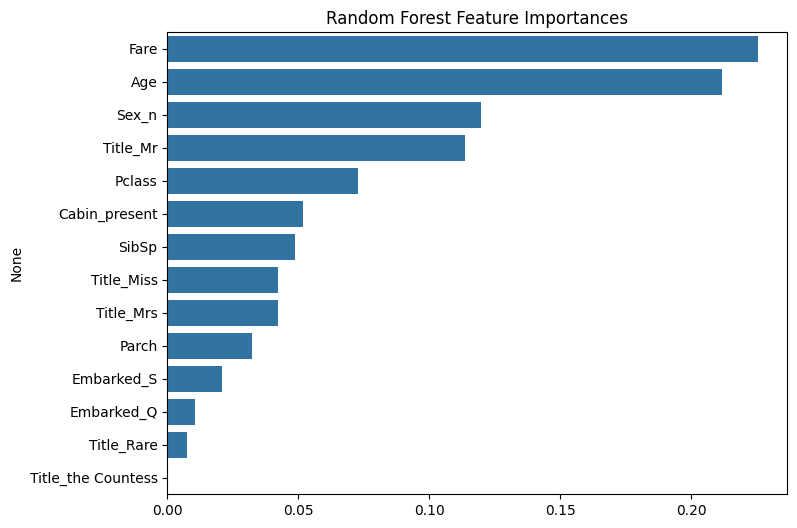

In [12]:
# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Random Forest Feature Importances')
plt.show()


In [13]:
# 7. Cost-complexity pruning for Decision Tree (post-pruning)
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
# Train trees for different alpha values
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)


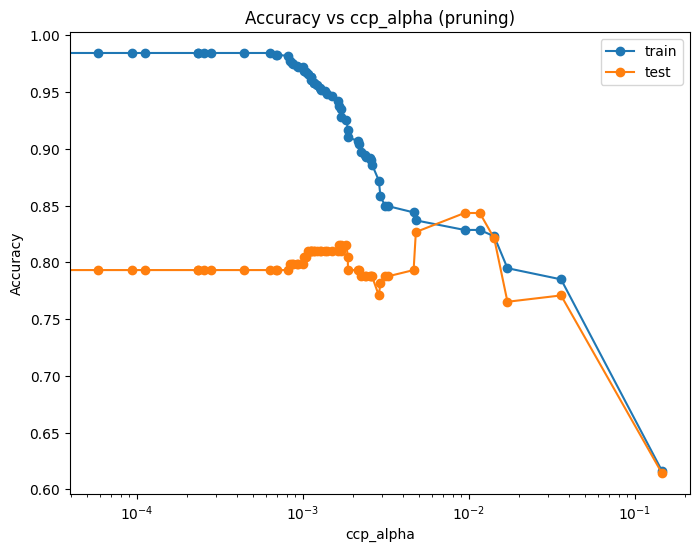

In [14]:
# Evaluate with cross-validation or on validation set
train_scores = [accuracy_score(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [accuracy_score(y_test, clf.predict(X_test)) for clf in clfs]

plt.figure(figsize=(8,6))
plt.plot(ccp_alphas, train_scores, marker='o', label='train')
plt.plot(ccp_alphas, test_scores, marker='o', label='test')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.xscale('log')
plt.legend()
plt.title('Accuracy vs ccp_alpha (pruning)')
plt.show()


In [15]:
# Choose best alpha based on validation/test performance
best_alpha = ccp_alphas[np.argmax(test_scores)]
pruned_dt = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
pruned_dt.fit(X_train, y_train)
y_pred_pruned = pruned_dt.predict(X_test)
print('Pruned Decision Tree Accuracy:', accuracy_score(y_test, y_pred_pruned))
print('Confusion Matrix:\\n', confusion_matrix(y_test, y_pred_pruned))
print('Classification Report:\\n', classification_report(y_test, y_pred_pruned))


Pruned Decision Tree Accuracy: 0.8435754189944135
Confusion Matrix:\n [[100  10]
 [ 18  51]]
Classification Report:\n               precision    recall  f1-score   support

           0       0.85      0.91      0.88       110
           1       0.84      0.74      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

